In [11]:
import zipfile
import os
import pandas as pd

# 1. Unzip of dataset
zip_path = 'Uber ride booking dataset.zip'
extract_to = 'uber_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# 2. What is in the files
print(f"Extracted files: {os.listdir(extract_to)}")

Extracted files: ['rideshare_kaggle.csv']


In [12]:
import os
print(os.getcwd())

c:\Users\Muiruri\Desktop\CODE\AI Programming Project\The Uber location predictor


In [13]:
# Load the data
csv_file = os.path.join(extract_to, 'rideshare_kaggle.csv') 
df = pd.read_csv(csv_file)

# The "First Look"
print("Data Shape:", df.shape)
display(df.head())
display(df.info()) 

Data Shape: (693071, 57)


,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


<class 'pandas.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           693071 non-null  str    
 1   timestamp                    693071 non-null  float64
 2   hour                         693071 non-null  int64  
 3   day                          693071 non-null  int64  
 4   month                        693071 non-null  int64  
 5   datetime                     693071 non-null  str    
 6   timezone                     693071 non-null  str    
 7   source                       693071 non-null  str    
 8   destination                  693071 non-null  str    
 9   cab_type                     693071 non-null  str    
 10  product_id                   693071 non-null  str    
 11  name                         693071 non-null  str    
 12  price                        637976 non-null  float64
 13  distance  

None

Here the data is cleaned in order to prevent noise from affecting the results

In [14]:
# Is there any missing data?
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 id                                 0
timestamp                          0
hour                               0
day                                0
month                              0
datetime                           0
timezone                           0
source                             0
destination                        0
cab_type                           0
product_id                         0
name                               0
price                          55095
distance                           0
surge_multiplier                   0
latitude                           0
longitude                          0
temperature                        0
apparentTemperature                0
short_summary                      0
long_summary                       0
precipIntensity                    0
precipProbability                  0
humidity                           0
windSpeed                          0
windGust                           0
windGustTime         

In [15]:
# Fill missing values in numeric columns with the mean of each column
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
print("Missing Values after imputation:\n", df.isnull().sum())

Missing Values after imputation:
 id                             0
timestamp                      0
hour                           0
day                            0
month                          0
datetime                       0
timezone                       0
source                         0
destination                    0
cab_type                       0
product_id                     0
name                           0
price                          0
distance                       0
surge_multiplier               0
latitude                       0
longitude                      0
temperature                    0
apparentTemperature            0
short_summary                  0
long_summary                   0
precipIntensity                0
precipProbability              0
humidity                       0
windSpeed                      0
windGust                       0
windGustTime                   0
visibility                     0
temperatureHigh                0
temperatu

In [16]:
# Lets check what columns actually exist in your DataFrame
print("Available columns:")
print(df.columns.tolist())
print("\nDataFrame info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())

Available columns:
['id', 'timestamp', 'hour', 'day', 'month', 'datetime', 'timezone', 'source', 'destination', 'cab_type', 'product_id', 'name', 'price', 'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature', 'apparentTemperature', 'short_summary', 'long_summary', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'windGustTime', 'visibility', 'temperatureHigh', 'temperatureHighTime', 'temperatureLow', 'temperatureLowTime', 'apparentTemperatureHigh', 'apparentTemperatureHighTime', 'apparentTemperatureLow', 'apparentTemperatureLowTime', 'icon', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'visibility.1', 'ozone', 'sunriseTime', 'sunsetTime', 'moonPhase', 'precipIntensityMax', 'uvIndexTime', 'temperatureMin', 'temperatureMinTime', 'temperatureMax', 'temperatureMaxTime', 'apparentTemperatureMin', 'apparentTemperatureMinTime', 'apparentTemperatureMax', 'apparentTemperatureMaxTime']

DataFrame info:
<class 'pandas.DataFrame'>
Ra

In [17]:
# Check for missing values in every column
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into a nice table
health_report = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percent})
print("--- DATASET HEALTH REPORT ---")
print(health_report[health_report['Missing Values'] > 0]) # Only show columns with issues

--- DATASET HEALTH REPORT ---
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


Since the data is clean,we create the criteria that the AI will use.That is hour,route and profit

In [18]:
# 1. Extract Hour from Timestamp
df['Hour'] = pd.to_datetime(df['timestamp'], errors='coerce').dt.hour

# 2. Create a 'Route' column by combining Pickup and Drop locations
df['Route'] = df['source'] + " to " + df['destination']

# 3. Calculate Profit (assuming $0.40/km cost)
df['Profit'] = df['price'] - (df['distance'] * 0.40)


# 4. Create a 'Traffic_Status' column based on surge_multiplier
# We define our own bins for Surge
# 1.0 = Low Traffic/Demand
# 1.1 to 1.5 = Medium
# Above 1.5 = High
def categorize_surge(surge):
    if surge > 1.5:
        return 'High'
    elif surge > 1.0:
        return 'Medium'
    else:
        return 'Low'

df['Traffic_Status'] = df['surge_multiplier'].apply(categorize_surge)

print("Features engineered. Ready for analysis!")

Features engineered. Ready for analysis!


The results show the result of the criteria applied above but grouped accordung to high surge times

In [19]:
# Grouping by our new Surge-based status
surge_analysis = df.groupby(['Hour', 'Route', 'Traffic_Status'])['Profit'].mean().reset_index()

# Find the top 10 most profitable routes during high surge times
top_surge_profits = surge_analysis.sort_values(by='Profit', ascending=False).reset_index(drop=True)

print("--- TOP PROFITS BY SURGE STATUS ---")
display(top_surge_profits.head(10))

--- TOP PROFITS BY SURGE STATUS ---


,Hour,Route,Traffic_Status,Profit
0,0,Financial District to Boston University,High,51.334182
1,0,Boston University to Financial District,High,50.593538
2,0,Fenway to Financial District,High,48.766240
3,0,Financial District to Fenway,High,47.203273
4,0,Theatre District to Boston University,High,47.067467
5,0,Northeastern University to Financial District,High,45.961833
6,0,Boston University to North Station,High,44.248471
7,0,Fenway to North Station,High,43.986444
8,0,Theatre District to Fenway,High,43.123455
9,0,Northeastern University to North Station,High,42.197333


Here,it is time to train the model but words have to be numerical

In [20]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
le_route = LabelEncoder()
le_traffic = LabelEncoder()

# Create a copy for the model so we don't mess up your original table
df_ml = df.copy()

# Transform text to numbers
df_ml['Route_n'] = le_route.fit_transform(df_ml['Route']) # type: ignore
df_ml['Traffic_n'] = le_traffic.fit_transform(df_ml['Traffic_Status']) # type: ignore

# Create a Target: 'Is_High_Profit' (1 if above average, 0 if below)
mean_profit = df_ml['Profit'].mean()
df_ml['Target'] = (df_ml['Profit'] > mean_profit).astype(int)

print("Encoding Complete!")
print(f"Routes are now numbers. Example: {df_ml['Route'].iloc[0]} -> {df_ml['Route_n'].iloc[0]}")

Encoding Complete!
Routes are now numbers. Example: Haymarket Square to North Station -> 33


In [21]:
from sklearn.model_selection import train_test_split

# Define X (Features) and y (Target)
X = df_ml[['Hour', 'Route_n', 'Traffic_n']]
y = df_ml['Target']

# Split: 80% for training, 20% for the test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} rows")
print(f"Testing set size: {len(X_test)} rows")

Training set size: 554456 rows
Testing set size: 138615 rows


In [22]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Initialize and Train
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

# 2. Predict and Evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Training Complete! Accuracy: {accuracy * 100:.2f}%")

Model Training Complete! Accuracy: 59.87%


The model accuracy of prediction was not satisfactory so to better the results,decision tree depth is increased and distance column is added

In [23]:
# 1. Update the Features (X) to include 'distance'
X_optimized = df_ml[['Hour', 'Route_n', 'Traffic_n', 'distance']] 
y = df_ml['Target']

# 2. Re-split the data using the new X
X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(X_optimized, y, test_size=0.2, random_state=42)

# 3. Train a "smarter" model by increasing max_depth to 5
better_model = DecisionTreeClassifier(max_depth=5, random_state=42)
better_model.fit(X_train_opt, y_train_opt)

# 4. Predict and check the new score
new_predictions = better_model.predict(X_test_opt)
new_accuracy = accuracy_score(y_test_opt, new_predictions)

print(f"Old Accuracy: 59.87%")
print(f"Optimized Accuracy: {new_accuracy * 100:.2f}%")

Old Accuracy: 59.87%
Optimized Accuracy: 60.58%


This is the decision tree visualization for decision making

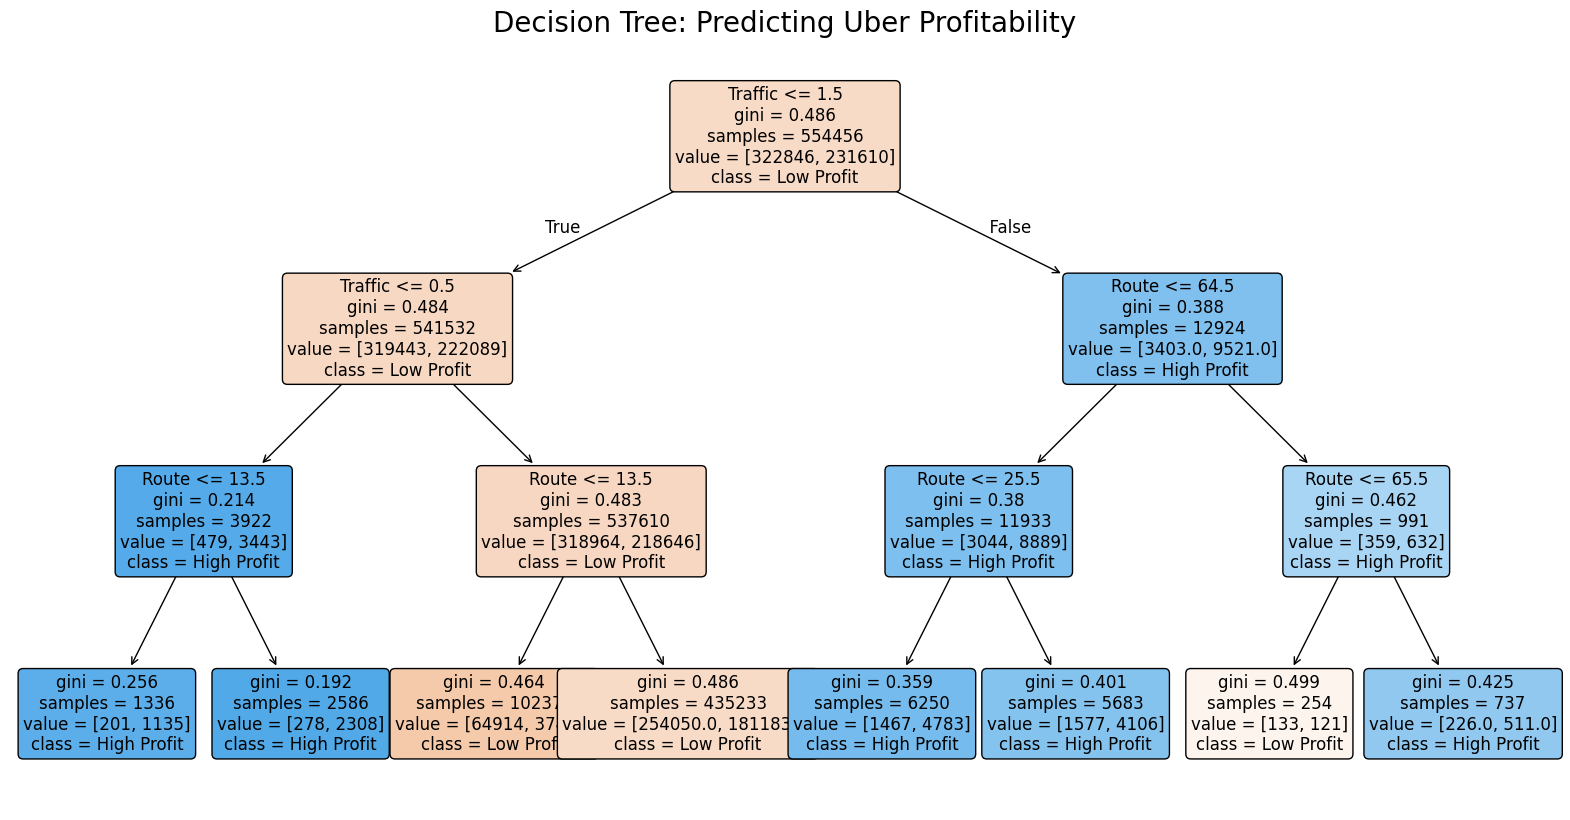

In [24]:
plt.figure(figsize=(20,10))
plot_tree(model, 
          feature_names=['Hour', 'Route', 'Traffic', 'Distance'], 
          class_names=['Low Profit', 'High Profit'], 
          filled=True, 
          rounded=True, 
          fontsize=12)

plt.title("Decision Tree: Predicting Uber Profitability", fontsize=20)
plt.show()

The AI is now complete.Drivers can input the hour,trip distance,routes and surge status to know what amount of profit it'll yield

In [27]:
def uber_profit_bot():
    print("--- 🚖 Uber Profit Assistant Bot ---")
    print("Enter trip details to see if it's worth your time.\n")

    try:
        # 1. Collect User Inputs using a simple command-line interface
        hour = int(input("What is the current hour? (0-23): "))
        distance = float(input("Estimated trip distance in miles?: "))
        
        print(f"Available Routes: {list(le_route.classes_[:5])}...") # Show some examples
        route_input = input("Enter Pickup to Dropoff (e.g., 'Financial District to Boston University'): ")
        
        traffic_input = input("Enter Traffic/Surge Status (Low, Medium, High): ")

        # 2. Transform inputs to match the Model's language
        # We use the same LabelEncoders from our training step
        route_encoded = le_route.transform([route_input])[0] # type: ignore
        traffic_encoded = le_traffic.transform([traffic_input])[0] # type: ignore

        # 3. Create a tiny dataframe for the prediction
        user_trip = pd.DataFrame([[hour, route_encoded, traffic_encoded, distance]], 
                                 columns=['Hour', 'Route_n', 'Traffic_n', 'distance'])

        # 4. The AI Decision
        prediction = better_model.predict(user_trip)[0]
        probability = better_model.predict_proba(user_trip)[0][1] # Chance of being high profit

        # 5.The result
        print("\n--- AI ANALYSIS ---")
        if prediction == 1:
            print(f"✅ GO FOR IT! This trip has a {probability*100:.1f}% chance of being HIGH PROFIT.")
        else:
            print(f"⚠️ PROCEED WITH CAUTION. This trip is predicted to be BELOW AVERAGE profit.")
            
    except ValueError:
        print("\n❌ Error: I don't recognize that Route or Traffic status. Please check your spelling!")

# Start the bot
uber_profit_bot()

--- 🚖 Uber Profit Assistant Bot ---
Enter trip details to see if it's worth your time.

Available Routes: ['Back Bay to Boston University', 'Back Bay to Fenway', 'Back Bay to Haymarket Square', 'Back Bay to North End', 'Back Bay to Northeastern University']...

--- AI ANALYSIS ---
✅ GO FOR IT! This trip has a 66.2% chance of being HIGH PROFIT.
